In [40]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine, load_digits
#loading dataset
wine = load_wine()

X_wine = wine.data
y_wine = wine.target

print("WINE DATASET")
print("Features:", X_wine.shape)
print("Classes:", np.unique(y_wine))
print("Target distribution:", np.bincount(y_wine))

digits = load_digits()

X_digits = digits.data
y_digits = digits.target

print("\nDIGITS DATASET")
print("Features:", X_digits.shape)
print("Classes:", np.unique(y_digits))
print("Target distribution:", np.bincount(y_digits))

WINE DATASET
Features: (178, 13)
Classes: [0 1 2]
Target distribution: [59 71 48]

DIGITS DATASET
Features: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]
Target distribution: [178 182 177 183 181 182 181 179 174 180]


In [41]:
print("\nWine:")
print(pd.DataFrame(X_wine, columns=wine.feature_names).head())

print("\nDigits:")
print(pd.DataFrame(X_digits).head())


Wine:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0           

Wine 7:3 with SVM

In [42]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
wine = load_wine()

X = wine.data
y = wine.target

# 70:30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 124
Testing samples: 54


SVM: Linear Without parameter


SVM - Linear Kernel
-------------------
Accuracy : 0.9629629629629629
Precision: 0.9639376218323586
Recall   : 0.9629629629629629
F1-score : 0.9628939284111699

Confusion Matrix:
[[18  0  0]
 [ 1 20  0]
 [ 0  1 14]]


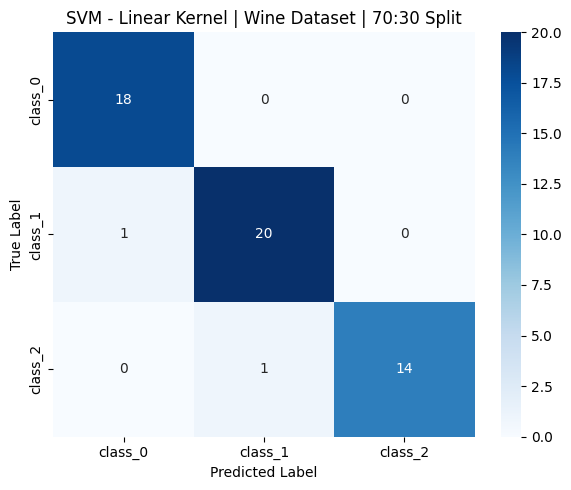

In [43]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# SVM - Linear Kernel
svm_linear = SVC(kernel='linear')

svm_linear.fit(X_train_scaled, y_train)

y_pred = svm_linear.predict(X_test_scaled)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

cm = confusion_matrix(y_test, y_pred)


print("SVM - Linear Kernel")
print("-------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nConfusion Matrix:")
print(cm)

# Confusion Matrix Heatmap

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM - Linear Kernel | Wine Dataset | 70:30 Split")

plt.tight_layout()
plt.show()

SVM -linear with parameter


Best Parameters: {'C': 0.01}
Best CV Accuracy: 0.984

Test Metrics
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Confusion Matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]


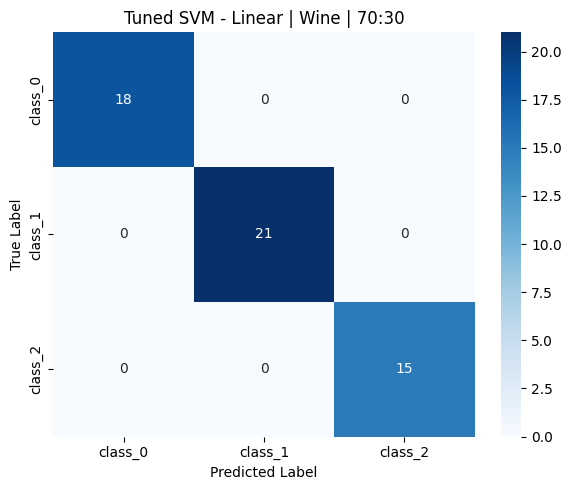

In [44]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Linear SVM - Parameter Tuning

linear_params = {
    'C': [0.01, 0.1, 1, 10, 100]
}

linear_grid = GridSearchCV(
    SVC(kernel='linear'),
    param_grid=linear_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

linear_grid.fit(X_train_scaled, y_train)

best_linear = linear_grid.best_estimator_

y_pred = best_linear.predict(X_test_scaled)

print("Best Parameters:", linear_grid.best_params_)
print("Best CV Accuracy:", linear_grid.best_score_)

print("\nTest Metrics")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1-score :", f1_score(y_test, y_pred, average='weighted'))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Tuned SVM - Linear | Wine | 70:30")

plt.tight_layout()
plt.show()

SVM: polynomial no parameter

SVM - Polynomial Kernel
-------------------
Accuracy : 0.9074074074074074
Precision: 0.9252136752136754
Recall   : 0.9074074074074074
F1-score : 0.9084845414632648

Confusion Matrix:
[[15  3  0]
 [ 0 21  0]
 [ 0  2 13]]


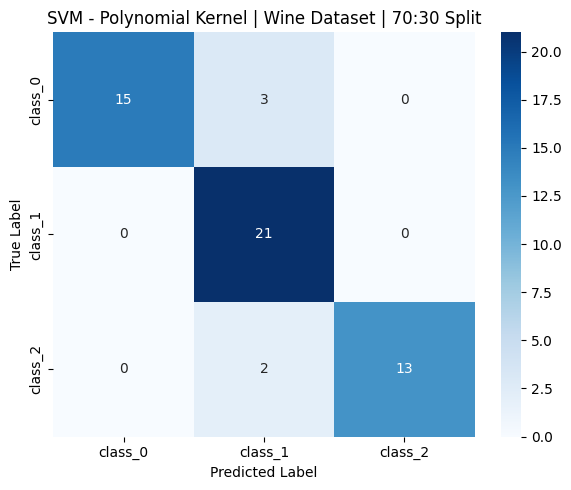

In [45]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# SVM - Linear Kernel
svm_linear = SVC(kernel='poly')

svm_linear.fit(X_train_scaled, y_train)

y_pred = svm_linear.predict(X_test_scaled)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

cm = confusion_matrix(y_test, y_pred)


print("SVM - Polynomial Kernel")
print("-------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nConfusion Matrix:")
print(cm)

# Confusion Matrix Heatmap

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM - Polynomial Kernel | Wine Dataset | 70:30 Split")

plt.tight_layout()
plt.show()

Polynomial with parameter

Best Parameters: {'C': 0.1, 'degree': 3, 'gamma': 1}
Best CV Accuracy: 0.9676666666666666

Test Metrics
Accuracy : 0.9259259259259259
Precision: 0.9296296296296297
Recall   : 0.9259259259259259
F1-score : 0.9255778334725704

Confusion Matrix:
[[18  0  0]
 [ 2 19  0]
 [ 0  2 13]]


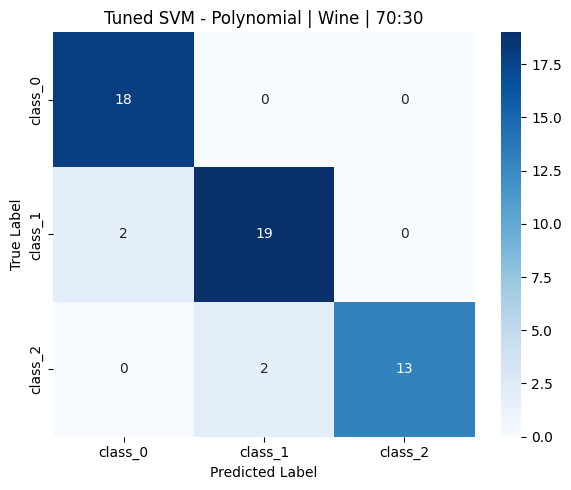

In [46]:
# Polynomial SVM - Parameter Tuning
poly_params = {
    'C': [0.1, 1, 10, 100],
    'degree': [2, 3, 4, 5],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

poly_grid = GridSearchCV(
    SVC(kernel='poly'),
    param_grid=poly_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

poly_grid.fit(X_train_scaled, y_train)

best_poly = poly_grid.best_estimator_

y_pred = best_poly.predict(X_test_scaled)

print("Best Parameters:", poly_grid.best_params_)
print("Best CV Accuracy:", poly_grid.best_score_)

print("\nTest Metrics")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1-score :", f1_score(y_test, y_pred, average='weighted'))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Tuned SVM - Polynomial | Wine | 70:30")

plt.tight_layout()
plt.show()

SVM - Gaussian no parameter

SVM - Gaussian Kernel
-------------------
Accuracy : 0.9814814814814815
Precision: 0.9823232323232324
Recall   : 0.9814814814814815
F1-score : 0.9813775282901185

Confusion Matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  1 14]]


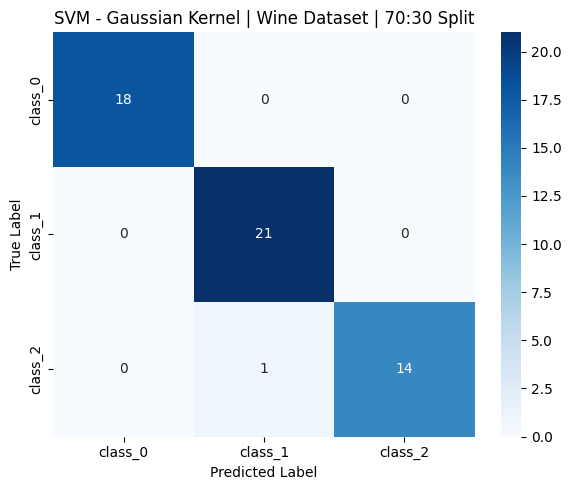

In [47]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# SVM - Linear Kernel
svm_linear = SVC(kernel='rbf')

svm_linear.fit(X_train_scaled, y_train)

y_pred = svm_linear.predict(X_test_scaled)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

cm = confusion_matrix(y_test, y_pred)


print("SVM - Gaussian Kernel")
print("-------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nConfusion Matrix:")
print(cm)

# Confusion Matrix Heatmap

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM - Gaussian Kernel | Wine Dataset | 70:30 Split")

plt.tight_layout()
plt.show()

Gaussian with parameter

Best Parameters: {'C': 1, 'gamma': 'scale'}
Best CV Accuracy: 0.992

Test Metrics
Accuracy : 0.9814814814814815
Precision: 0.9823232323232324
Recall   : 0.9814814814814815
F1-score : 0.9813775282901185

Confusion Matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  1 14]]


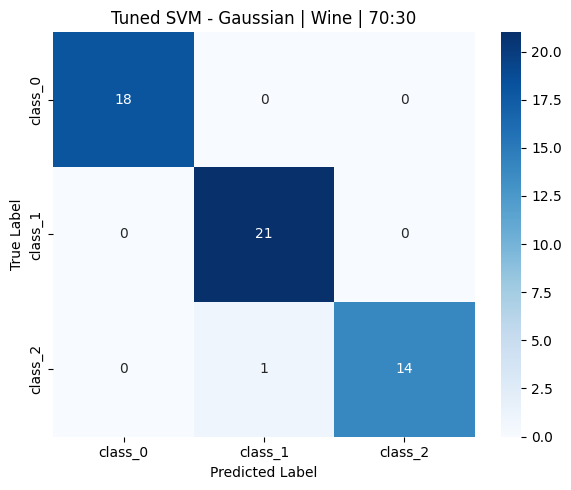

In [48]:
# RBF SVM - Parameter Tuning

rbf_params = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

rbf_grid = GridSearchCV(
    SVC(kernel='rbf'),
    param_grid=rbf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rbf_grid.fit(X_train_scaled, y_train)

best_rbf = rbf_grid.best_estimator_

y_pred = best_rbf.predict(X_test_scaled)

print("Best Parameters:", rbf_grid.best_params_)
print("Best CV Accuracy:", rbf_grid.best_score_)

print("\nTest Metrics")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1-score :", f1_score(y_test, y_pred, average='weighted'))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Tuned SVM - Gaussian | Wine | 70:30")

plt.tight_layout()
plt.show()

SVM - Sigmoid no parameter

SVM - Sigmoid Kernel
-------------------
Accuracy : 0.9629629629629629
Precision: 0.9650950292397661
Recall   : 0.9629629629629629
F1-score : 0.9625859730698442

Confusion Matrix:
[[18  0  0]
 [ 1 19  1]
 [ 0  0 15]]


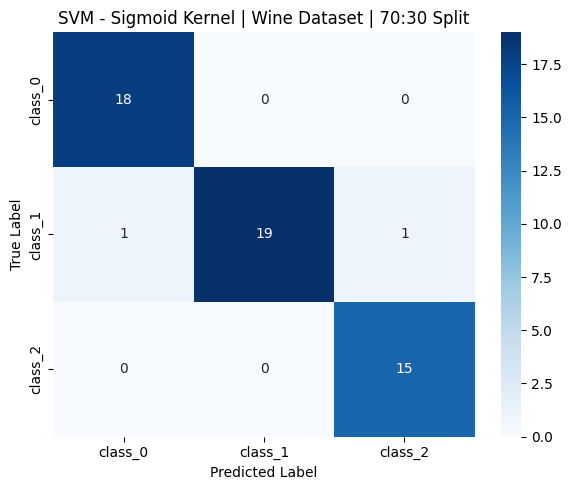

In [49]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# SVM - Linear Kernel
svm_linear = SVC(kernel='sigmoid')

svm_linear.fit(X_train_scaled, y_train)

y_pred = svm_linear.predict(X_test_scaled)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

cm = confusion_matrix(y_test, y_pred)


print("SVM - Sigmoid Kernel")
print("-------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nConfusion Matrix:")
print(cm)

# Confusion Matrix Heatmap

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM - Sigmoid Kernel | Wine Dataset | 70:30 Split")

plt.tight_layout()
plt.show()

Sigmoid with parameter

Best Parameters: {'C': 1, 'gamma': 0.01}
Best CV Accuracy: 0.984

Test Metrics
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Confusion Matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]


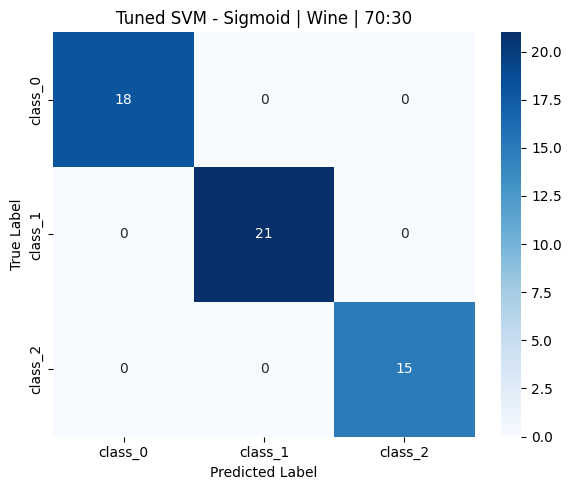

In [50]:
# Sigmoid SVM - Parameter Tuning

sigmoid_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

sigmoid_grid = GridSearchCV(
    SVC(kernel='sigmoid'),
    param_grid=sigmoid_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

sigmoid_grid.fit(X_train_scaled, y_train)

best_sigmoid = sigmoid_grid.best_estimator_

y_pred = best_sigmoid.predict(X_test_scaled)

print("Best Parameters:", sigmoid_grid.best_params_)
print("Best CV Accuracy:", sigmoid_grid.best_score_)

print("\nTest Metrics")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1-score :", f1_score(y_test, y_pred, average='weighted'))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Tuned SVM - Sigmoid | Wine | 70:30")

plt.tight_layout()
plt.show()

MLP

MLP - No parameter tuning

MLP - Default Parameters
------------------------
Accuracy : 0.9814814814814815
Precision: 0.9824561403508772
Recall   : 0.9814814814814815
F1-score : 0.9815058961400425

Confusion Matrix:
[[18  0  0]
 [ 1 20  0]
 [ 0  0 15]]


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


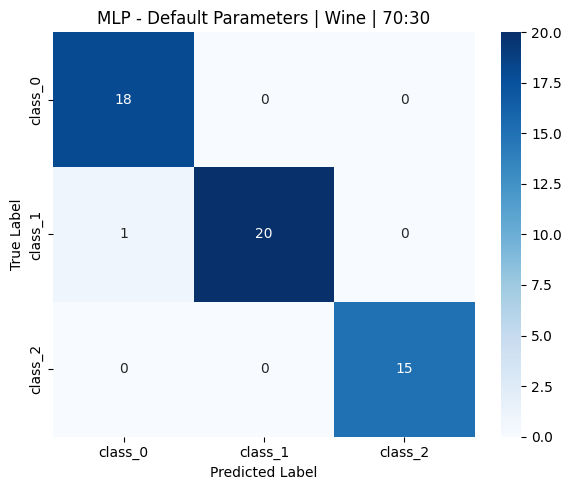

In [51]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# MLP - Default Parameters

mlp = MLPClassifier()

mlp.fit(X_train_scaled, y_train)

y_pred = mlp.predict(X_test_scaled)

# Evaluation Metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

cm = confusion_matrix(y_test, y_pred)

print("MLP - Default Parameters")
print("------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nConfusion Matrix:")
print(cm)

# Confusion Matrix Heatmap

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MLP - Default Parameters | Wine | 70:30")

plt.tight_layout()
plt.show()
print()
print()


MLP TUNNED

MLP - Parameterized
-------------------
Momentum     : 0.9
Epochs       : 500
Learning Rate: 0.01

Accuracy : 0.9629629629629629
Precision: 0.9629629629629629
Recall   : 0.9629629629629629
F1-score : 0.9629629629629629

Confusion Matrix:
[[18  0  0]
 [ 0 20  1]
 [ 0  1 14]]


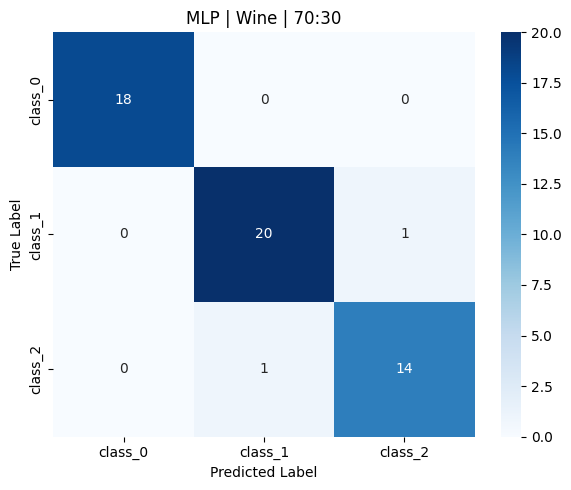

In [52]:
mlp = MLPClassifier(
    momentum=0.9,
    max_iter=500,
    learning_rate_init=0.01,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

y_pred = mlp.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

cm = confusion_matrix(y_test, y_pred)

print("MLP - Parameterized")
print("-------------------")
print("Momentum     :", 0.9)
print("Epochs       :", 500)
print("Learning Rate:", 0.01)

print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MLP | Wine | 70:30")
plt.tight_layout()
plt.show()

RANDOM FOREST WITHOUT PARAMETER TUNING

Random Forest - Default
-----------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Confusion Matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]


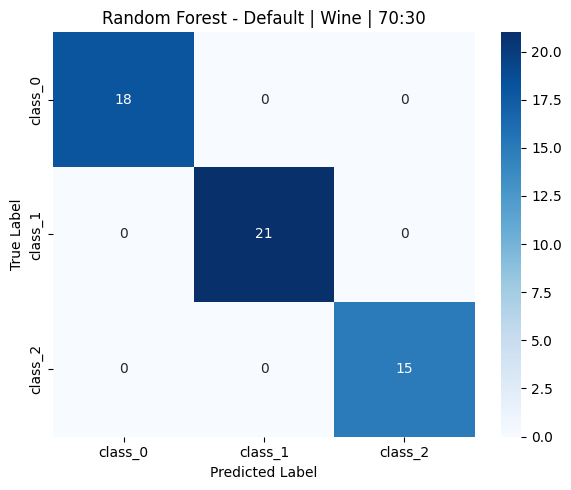

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest - Default

rfc = RandomForestClassifier(random_state=42)

rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)

# Metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

cm = confusion_matrix(y_test, y_pred)

print("Random Forest - Default")
print("-----------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nConfusion Matrix:")
print(cm)

# Heatmap

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest - Default | Wine | 70:30")

plt.tight_layout()
plt.show()

RANDOM FOREST WITH PARAMETER TUNING

Random Forest - Parameterized
-----------------------------
Trees             : 200
Max Depth         : 10
Min Samples Split : 2

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Confusion Matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]


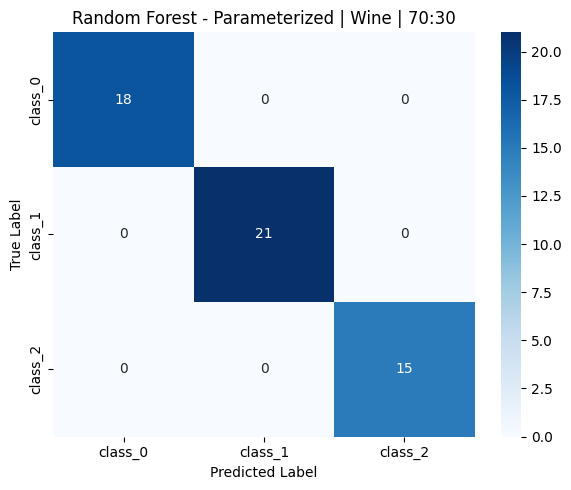

In [54]:
rfc_param = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

rfc_param.fit(X_train, y_train)

y_pred = rfc_param.predict(X_test)


# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

cm = confusion_matrix(y_test, y_pred)

print("Random Forest - Parameterized")
print("-----------------------------")
print("Trees             :", 200)
print("Max Depth         :", 10)
print("Min Samples Split :", 2)

print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nConfusion Matrix:")
print(cm)


# Heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest - Parameterized | Wine | 70:30")

plt.tight_layout()
plt.show()

GENERAL SPLITTING FUNCTION

In [55]:
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


def evaluate_split(X, y, test_size, model, model_name, dataset_name="Wine"):
    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )
    # Scaling
    if model_name in ["SVC", "MLP"]:

        scaler = StandardScaler()

        X_train_used = scaler.fit_transform(X_train)
        X_test_used = scaler.transform(X_test)

    else:

        X_train_used = X_train
        X_test_used = X_test
    # Train Model
    model.fit(X_train_used, y_train)
    # Prediction
    y_pred = model.predict(X_test_used)
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    cm = confusion_matrix(y_test, y_pred)
    # Print Results
    print("=" * 50)

    print(
        f"{model_name} | {dataset_name} | "
        f"Train {int((1-test_size)*100)}:"
        f"{int(test_size*100)}"
    )

    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    # Confusion Matrix Heatmap
    plt.figure(figsize=(6, 5))

    # Use dataset-specific class labels
    if dataset_name == "Wine":
        class_names = wine.target_names
    else:
        class_names = np.unique(y)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.title(
        f"{model_name} | {dataset_name} | "
        f"{int((1-test_size)*100)}:"
        f"{int(test_size*100)}"
    )

    plt.tight_layout()
    plt.show()
    print()
    # Training / Loss Curve
    if model_name == "MLP":
        # MLP has an actual loss curve

        plt.figure(figsize=(8, 5))

        plt.plot(
            range(1, len(model.loss_curve_) + 1),
            model.loss_curve_,
            label="Training Loss"
        )

        plt.xlabel("Epoch")
        plt.ylabel("Loss")

        plt.title(
            f"MLP Training Loss Curve | "
            f"{dataset_name} | "
            f"{int((1-test_size)*100)}:"
            f"{int(test_size*100)}"
        )

        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        print()
    else:
        # SVC / RFC don't have loss_curve_
        # Using learning curve instead

        train_sizes, train_scores, validation_scores = learning_curve(
            model,
            X_train_used,
            y_train,
            cv=5,
            scoring="accuracy",
            train_sizes=np.linspace(0.1, 1.0, 10),
            n_jobs=-1
        )

        train_mean = train_scores.mean(axis=1)
        validation_mean = validation_scores.mean(axis=1)

        plt.figure(figsize=(8, 5))

        plt.plot(
            train_sizes,
            train_mean,
            marker="o",
            label="Training Accuracy"
        )

        plt.plot(
            train_sizes,
            validation_mean,
            marker="o",
            label="Validation Accuracy"
        )

        plt.xlabel("Training Set Size")
        plt.ylabel("Accuracy")

        plt.title(
            f"{model_name} Learning Curve | "
            f"{dataset_name} | "
            f"{int((1-test_size)*100)}:"
            f"{int(test_size*100)}"
        )

        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Return Results
    return {
        "Model": model_name,
        "Split": (
            f"{int((1-test_size)*100)}:"
            f"{int(test_size*100)}"
        ),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

FOR BEST TEST CASE RESULTS OF TESTING

In [56]:
best_svc = SVC(
    kernel="linear"
)

best_mlp = MLPClassifier(
    momentum=0.9,
    max_iter=500,
    learning_rate_init=0.01,
    random_state=42
)

best_rfc = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

FOR ALL THE SPLIT AND ALL THE MODELS

SVC | Wine | Train 50:50
Accuracy : 0.9551
Precision: 0.9558
Recall   : 0.9551
F1-score : 0.9548

Confusion Matrix:
[[30  0  0]
 [ 2 32  1]
 [ 0  1 23]]


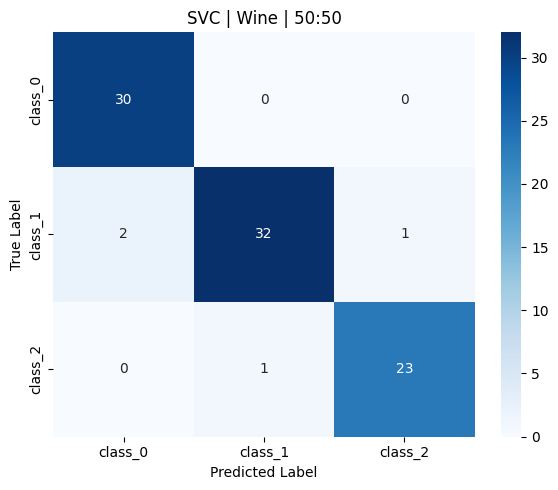

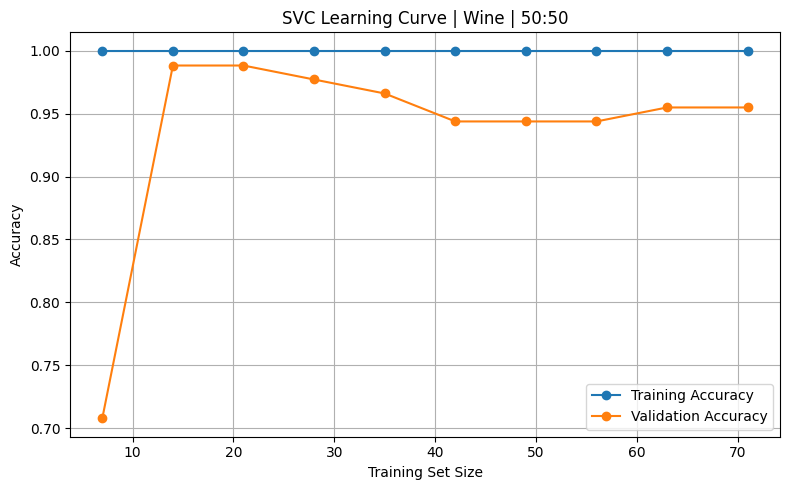

MLP | Wine | Train 50:50
Accuracy : 0.9551
Precision: 0.9558
Recall   : 0.9551
F1-score : 0.9548

Confusion Matrix:
[[30  0  0]
 [ 2 32  1]
 [ 0  1 23]]


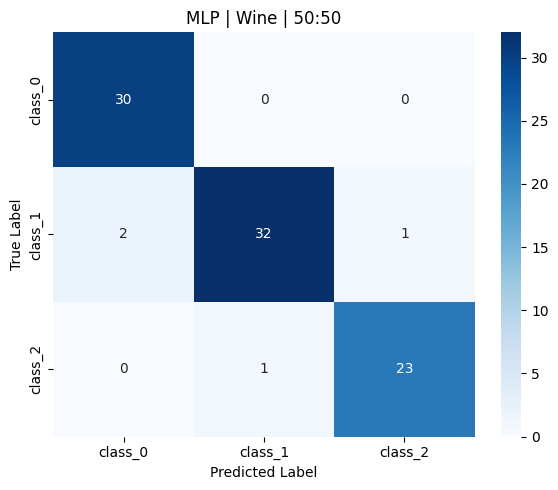

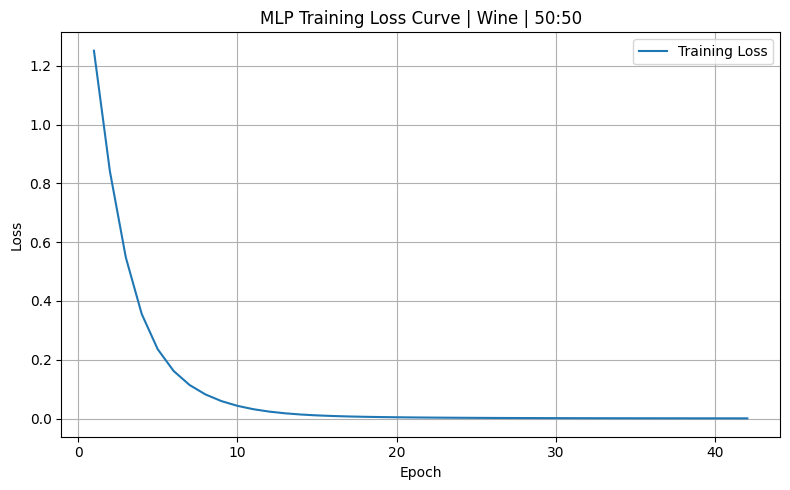


RFC | Wine | Train 50:50
Accuracy : 0.9775
Precision: 0.9783
Recall   : 0.9775
F1-score : 0.9774

Confusion Matrix:
[[30  0  0]
 [ 1 33  1]
 [ 0  0 24]]


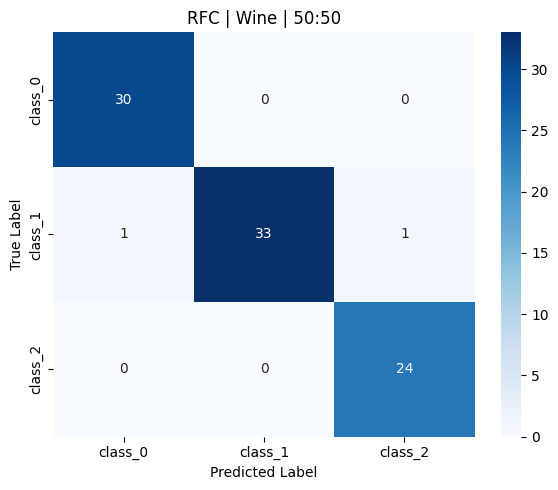

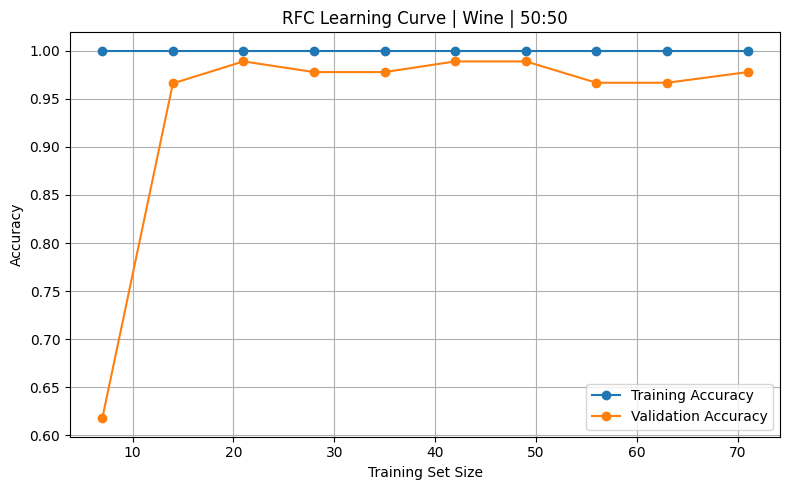

SVC | Wine | Train 60:40
Accuracy : 0.9583
Precision: 0.9600
Recall   : 0.9583
F1-score : 0.9583

Confusion Matrix:
[[24  0  0]
 [ 2 27  0]
 [ 0  1 18]]


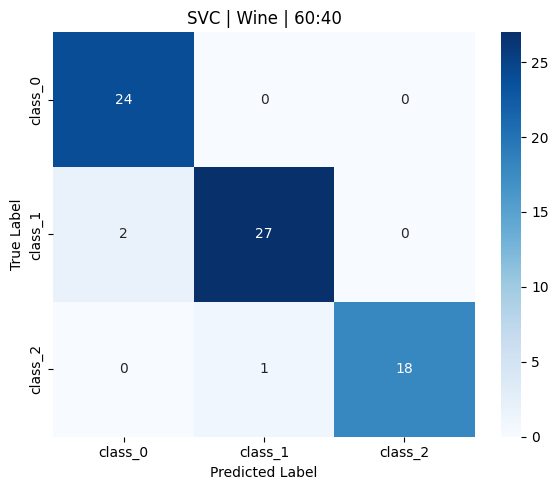

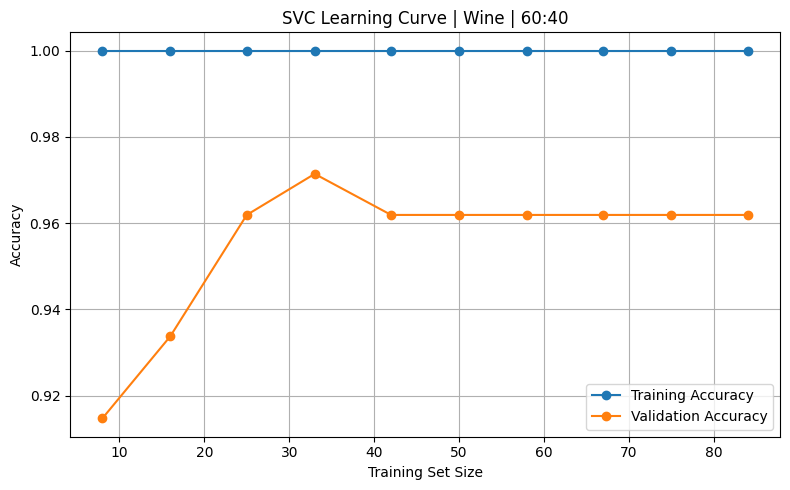

MLP | Wine | Train 60:40
Accuracy : 0.9722
Precision: 0.9728
Recall   : 0.9722
F1-score : 0.9722

Confusion Matrix:
[[24  0  0]
 [ 1 28  0]
 [ 0  1 18]]


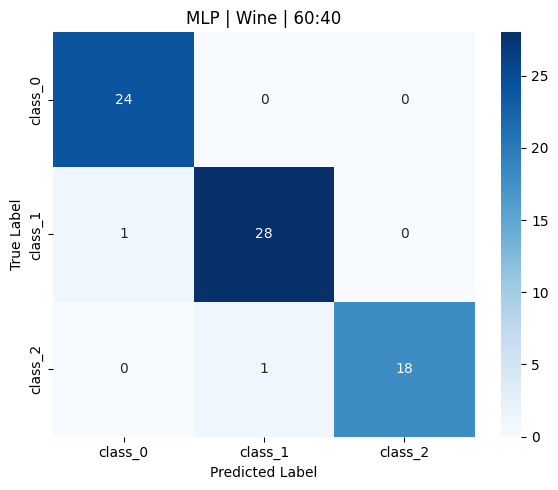

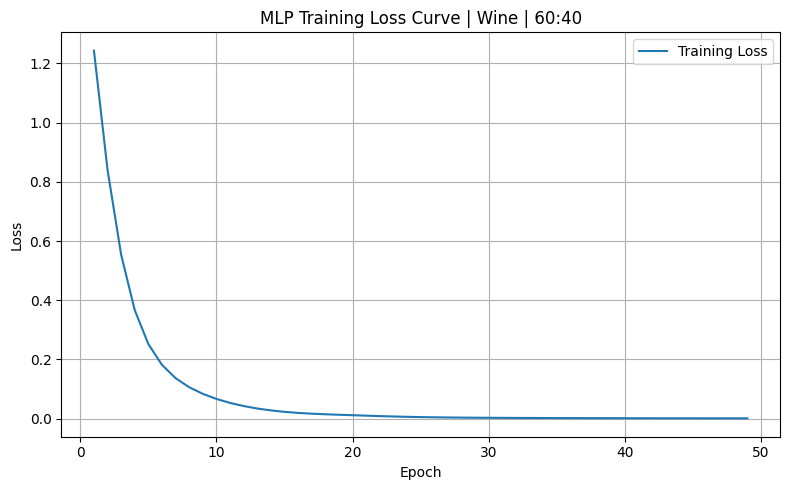


RFC | Wine | Train 60:40
Accuracy : 0.9861
Precision: 0.9867
Recall   : 0.9861
F1-score : 0.9861

Confusion Matrix:
[[24  0  0]
 [ 1 28  0]
 [ 0  0 19]]


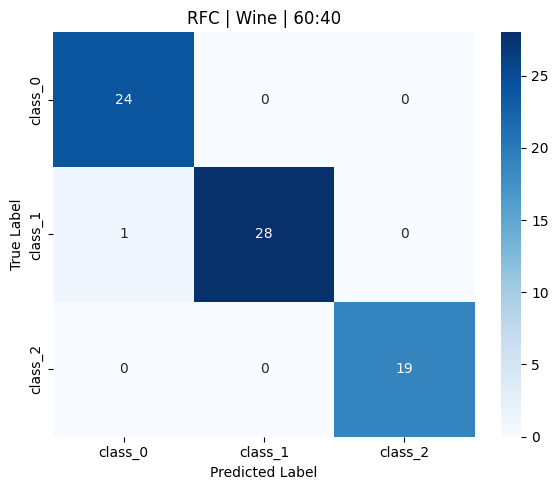

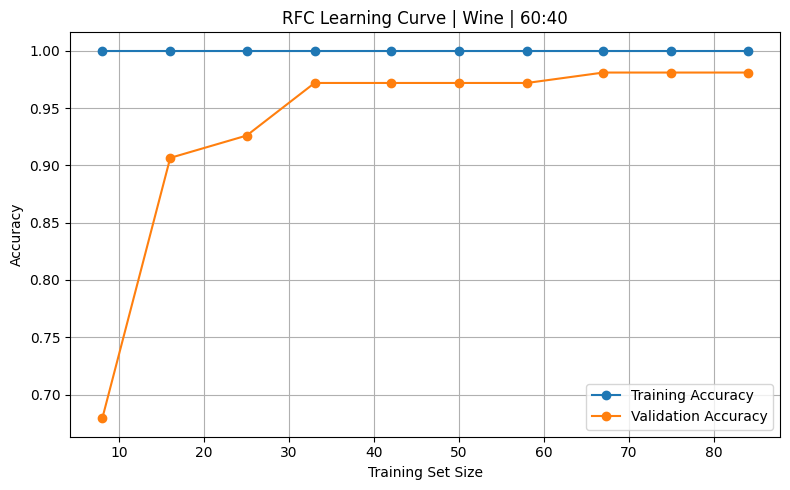

SVC | Wine | Train 70:30
Accuracy : 0.9630
Precision: 0.9639
Recall   : 0.9630
F1-score : 0.9629

Confusion Matrix:
[[18  0  0]
 [ 1 20  0]
 [ 0  1 14]]


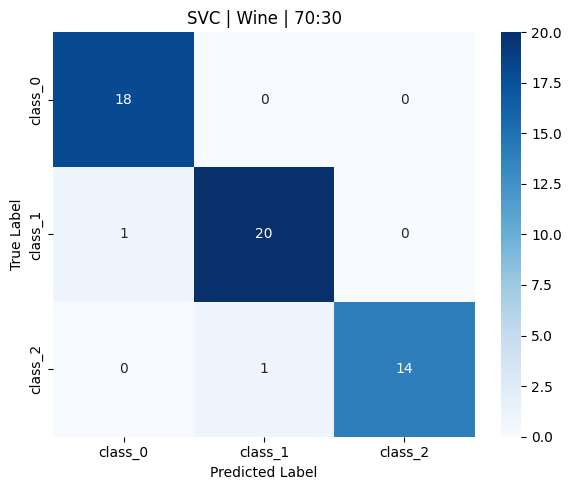

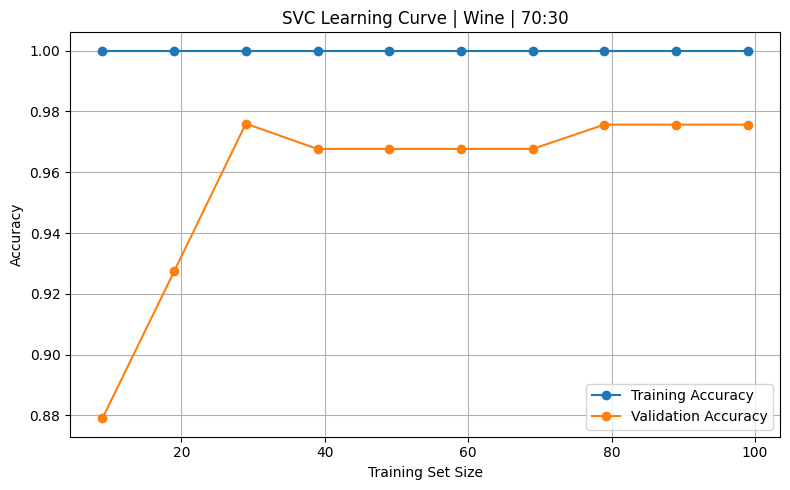

MLP | Wine | Train 70:30
Accuracy : 0.9630
Precision: 0.9630
Recall   : 0.9630
F1-score : 0.9630

Confusion Matrix:
[[18  0  0]
 [ 0 20  1]
 [ 0  1 14]]


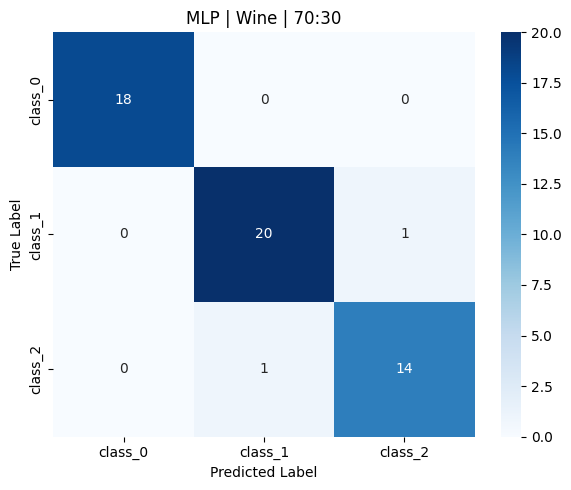

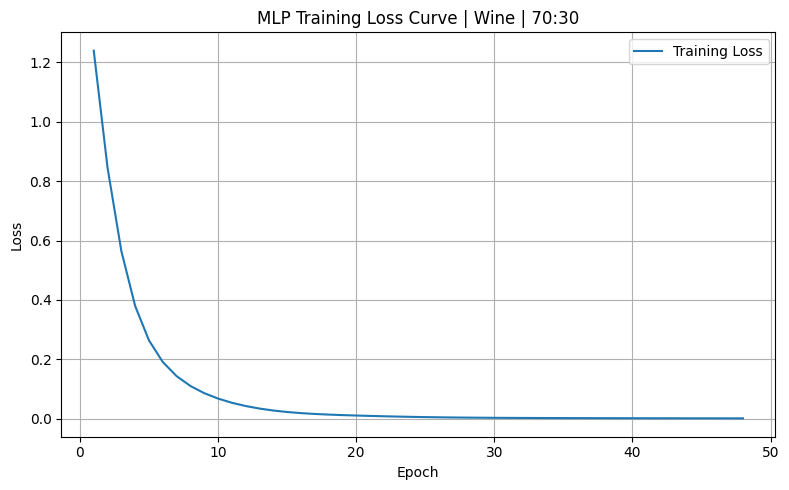


RFC | Wine | Train 70:30
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Confusion Matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]


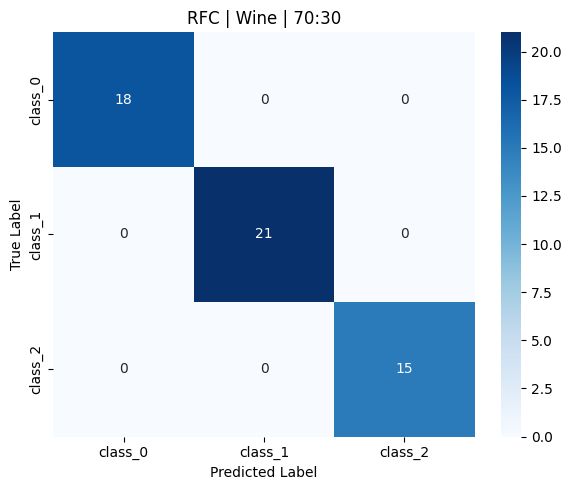

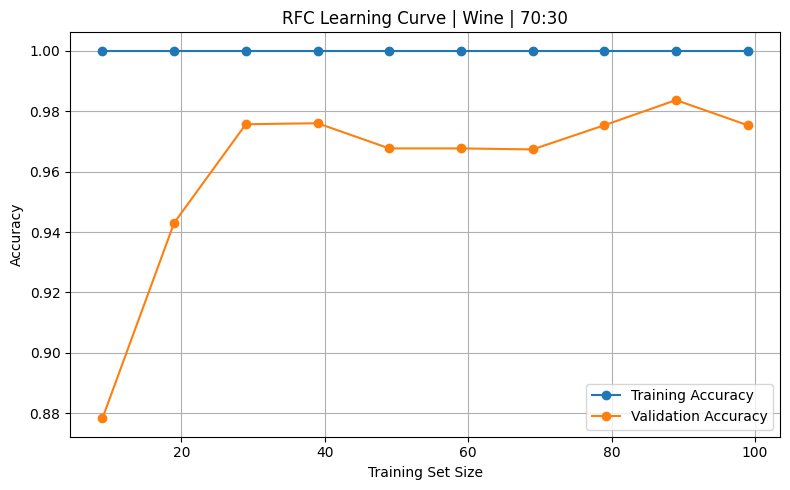

SVC | Wine | Train 80:20
Accuracy : 0.9444
Precision: 0.9466
Recall   : 0.9444
F1-score : 0.9443

Confusion Matrix:
[[12  0  0]
 [ 1 13  0]
 [ 0  1  9]]


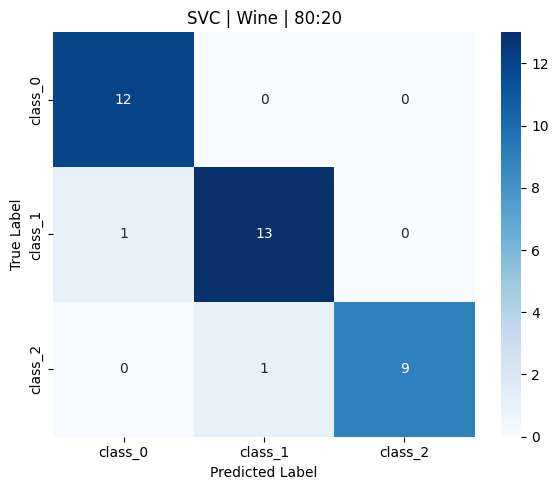

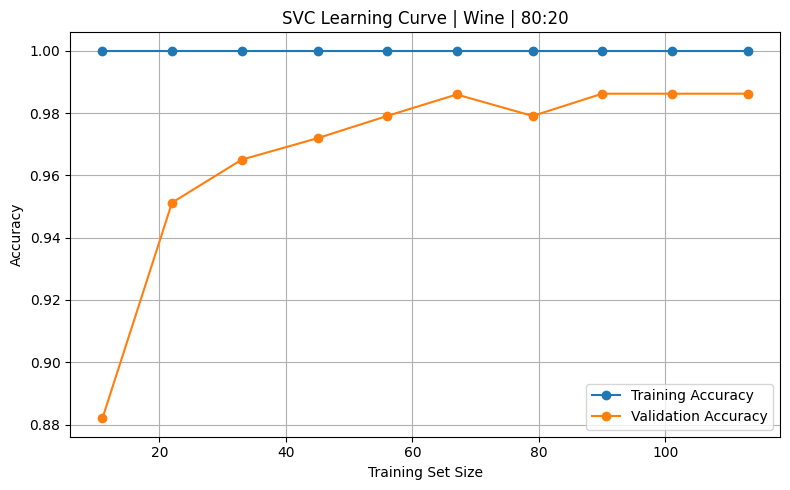

MLP | Wine | Train 80:20
Accuracy : 0.9722
Precision: 0.9741
Recall   : 0.9722
F1-score : 0.9720

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


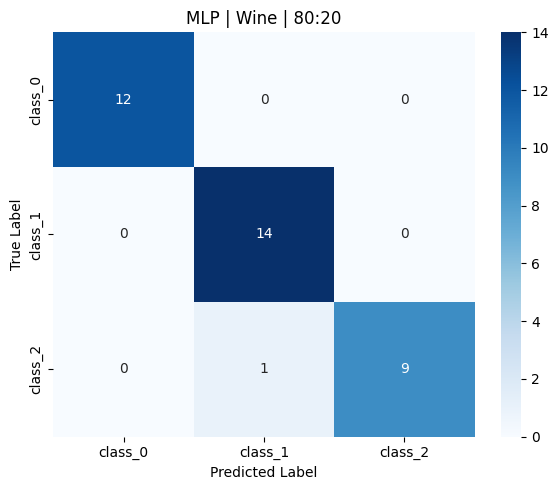

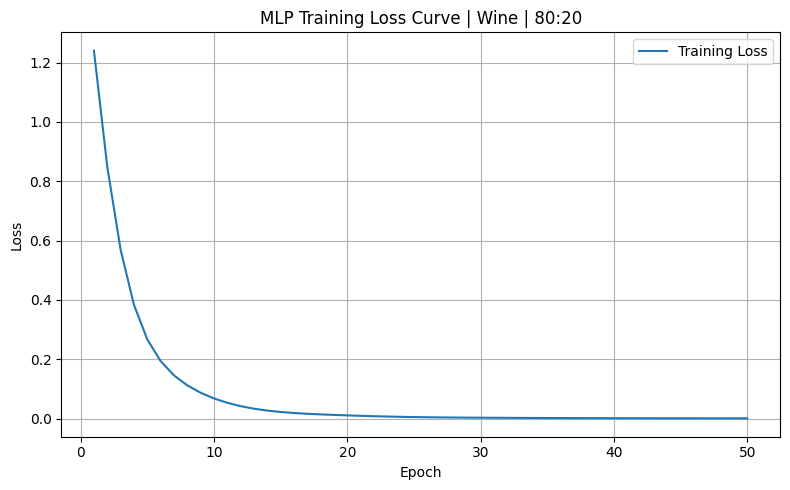


RFC | Wine | Train 80:20
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


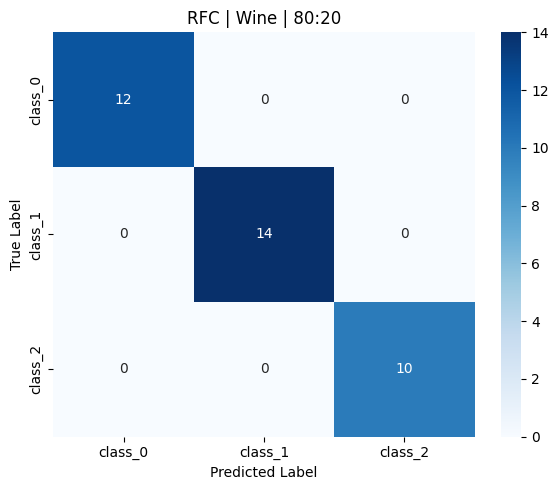

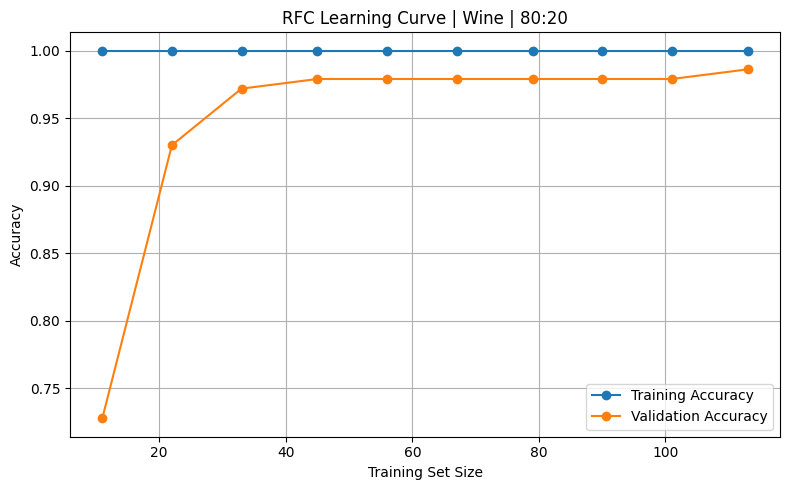

In [57]:
results = []

splits = [0.50, 0.40, 0.30, 0.20]

for test_size in splits:

    results.append(
        evaluate_split(
            X_wine if 'X_wine' in globals() else X,
            y_wine if 'y_wine' in globals() else y,
            test_size,
            best_svc,
            "SVC"
        )
    )

    results.append(
        evaluate_split(
            X_wine if 'X_wine' in globals() else X,
            y_wine if 'y_wine' in globals() else y,
            test_size,
            best_mlp,
            "MLP"
        )
    )

    results.append(
        evaluate_split(
            X_wine if 'X_wine' in globals() else X,
            y_wine if 'y_wine' in globals() else y,
            test_size,
            best_rfc,
            "RFC"
        )
    )

generate an image illustrating Receiver Operating Characteristic (ROC)
curve and Area Under the Curve (AUC) for every classifier.

In [58]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np


def plot_roc_auc(X, y, models, dataset_name="Wine"):


    # Train-test split


    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )


    # Convert labels to One-vs-Rest format


    classes = np.unique(y)

    y_test_bin = label_binarize(
        y_test,
        classes=classes
    )

    plt.figure(figsize=(8, 6))



    # Train and ROC for each classifier


    for model_name, model in models.items():

        # Scale SVC and MLP
        if model_name in ["SVC", "MLP"]:

            scaler = StandardScaler()

            X_train_used = scaler.fit_transform(X_train)
            X_test_used = scaler.transform(X_test)

        else:

            X_train_used = X_train
            X_test_used = X_test


        # Train
        model.fit(
            X_train_used,
            y_train
        )


        # Get prediction probabilities / decision scores

        if hasattr(model, "predict_proba"):

            y_score = model.predict_proba(
                X_test_used
            )

        else:

            y_score = model.decision_function(
                X_test_used
            )


        # Calculate ROC for every class

        fpr = {}
        tpr = {}
        roc_auc = {}

        for i in range(len(classes)):

            fpr[i], tpr[i], _ = roc_curve(
                y_test_bin[:, i],
                y_score[:, i]
            )

            roc_auc[i] = auc(
                fpr[i],
                tpr[i]
            )


        # Macro-average ROC

        all_fpr = np.unique(
            np.concatenate(
                [fpr[i] for i in range(len(classes))]
            )
        )

        mean_tpr = np.zeros_like(all_fpr)

        for i in range(len(classes)):

            mean_tpr += np.interp(
                all_fpr,
                fpr[i],
                tpr[i]
            )

        mean_tpr /= len(classes)

        macro_auc = auc(
            all_fpr,
            mean_tpr
        )


        # Plot

        plt.plot(
            all_fpr,
            mean_tpr,
            linewidth=2,
            label=f"{model_name} (AUC = {macro_auc:.3f})"
        )



    # Random Classifier


    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random Classifier"
    )



    # Labels

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(
        f"ROC Curves - {dataset_name} | 70:30 Split"
    )

    plt.legend(
        loc="lower right"
    )

    plt.grid(True)

    plt.tight_layout()

    plt.show()

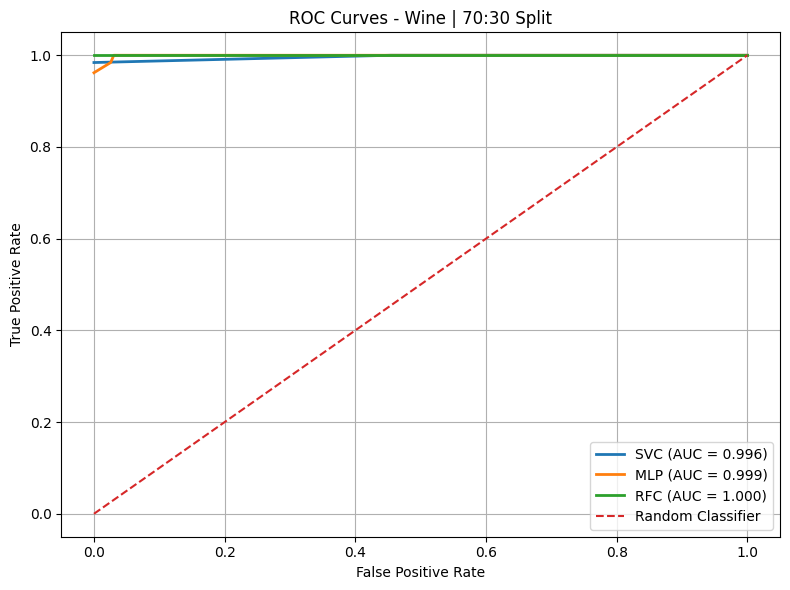

In [59]:
models = {
    "SVC": best_svc,
    "MLP": best_mlp,
    "RFC": best_rfc
}

plot_roc_auc(
    X_wine,
    y_wine,
    models,
    "Wine"
)

PCA FEATURE ON BEST OUTCOME CLASSIFIERS

Original number of features: 13
Reduced number of features : 10
Explained variance ratio   : [0.35730453 0.19209164 0.11006755 0.07250719 0.06973166 0.05341402
 0.04555029 0.0241568  0.02040417 0.01976974]
Total explained variance   : 0.9649975826158312

SVC | Wine | PCA
Accuracy : 0.9444
Precision: 0.9472
Recall   : 0.9444
F1-score : 0.9444

Confusion Matrix:
[[18  0  0]
 [ 2 19  0]
 [ 0  1 14]]


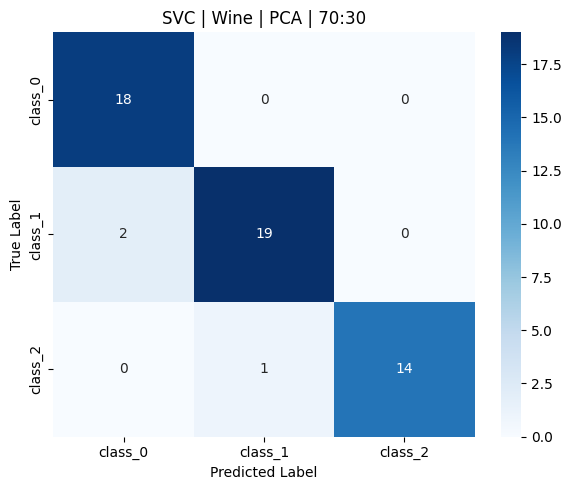


MLP | Wine | PCA
Accuracy : 0.9815
Precision: 0.9825
Recall   : 0.9815
F1-score : 0.9815

Confusion Matrix:
[[18  0  0]
 [ 1 20  0]
 [ 0  0 15]]


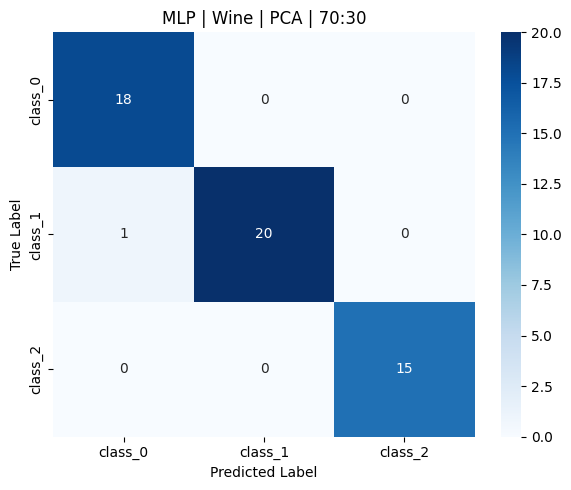


RFC | Wine | PCA
Accuracy : 0.9630
Precision: 0.9630
Recall   : 0.9630
F1-score : 0.9630

Confusion Matrix:
[[17  1  0]
 [ 1 20  0]
 [ 0  0 15]]


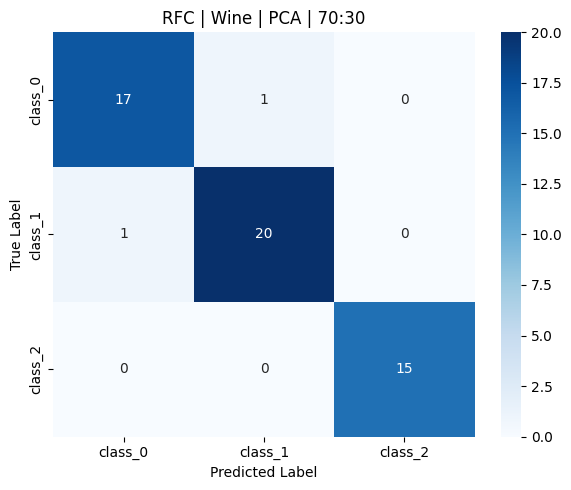


PCA RESULTS
Model  Accuracy  Precision   Recall  F1-score
  SVC  0.944444   0.947222 0.944444  0.944422
  MLP  0.981481   0.982456 0.981481  0.981506
  RFC  0.962963   0.962963 0.962963  0.962963


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# 1. Wine 70:30 Split

X_train, X_test, y_train, y_test = train_test_split(
    X_wine,
    y_wine,
    test_size=0.30,
    random_state=42,
    stratify=y_wine
)


# 2. Standardization

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 3. PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


print("Original number of features:", X_train.shape[1])
print("Reduced number of features :", X_train_pca.shape[1])
print("Explained variance ratio   :", pca.explained_variance_ratio_)
print("Total explained variance   :", pca.explained_variance_ratio_.sum())


# 4. Define Best Models

models = {
    "SVC": best_svc,
    "MLP": best_mlp,
    "RFC": best_rfc
}


# 5. Train and Evaluate

pca_results = []

for model_name, model in models.items():

    model.fit(X_train_pca, y_train)

    y_pred = model.predict(X_test_pca)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    cm = confusion_matrix(y_test, y_pred)
    # Print Resul

    print("\n" + "=" * 50)
    print(f"{model_name} | Wine | PCA")
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)
    # Confusion Matrix Heatm

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=wine.target_names,
        yticklabels=wine.target_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.title(
        f"{model_name} | Wine | PCA | 70:30"
    )

    plt.tight_layout()
    plt.show()


    # Store results
    pca_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })


# 6. Comparison Table

pca_results_df = pd.DataFrame(pca_results)

print("\nPCA RESULTS")
print(pca_results_df.to_string(index=False))